# Bi-orthogonal Embedding — Visual Exploration

Explore the `biort` bi-orthogonal embedding of the *Drosophila* central-complex
ring connectome. Two passes:

1. **EPG only** — the ring-attractor population; ring/angular structure should be cleanest.
2. **Delta7 + EPG** — the full compass circuit; how the two populations separate.

Preprocessing is factored into `scripts/ring_preprocessing.py`; the embedding is
`biort.BiorthEmbedding`. Each panel is rendered interactively (Plotly, hover for
neuron id / instance / cell type / group) and saved as a static PDF to `figures/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

from ring_preprocessing import load_ring_connectome
from biort import BiorthEmbedding

try:
    import umap  # optional
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False

FIG_DIR = os.path.join(os.getcwd(), '..', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def save_pdf(fig, name):
    """Save a matplotlib figure as figures/<name>.pdf."""
    path = os.path.join(FIG_DIR, name + '.pdf')
    fig.savefig(path, bbox_inches='tight')
    print('saved', path)

def show_plotly(fig):
    """Render a Plotly figure, no-op if no renderer is available (headless)."""
    try:
        fig.show()
    except Exception as e:
        print('plotly render skipped:', e)

In [2]:
def fit_embedding(rc, k=8, alpha=0.95, random_state=42):
    """Fit the real (clustering) and complex (modes) embeddings; return a bundle."""
    be = BiorthEmbedding(k=k, alpha=alpha, realify=True, random_state=random_state).fit(rc.A)
    be_c = BiorthEmbedding(k=k, alpha=alpha, realify=False, random_state=random_state).fit(rc.A)
    X = be.get_embedding()                 # (n, 2k) real: [Re(V) | Re(U)]
    U_c, V_c, Lam_c = be_c.get_modes()     # complex left/right modes, slow eigenvalues
    cg = be.get_coarse_graph()
    return dict(
        rc=rc, k=k, be=be, be_c=be_c, X=X, Xf=X[:, :k], Xb=X[:, k:2*k],
        groups=np.asarray(be.groups_), pi=np.asarray(be.pi_),
        U_c=U_c, V_c=V_c, Lam_c=Lam_c, fidelity=cg['fidelity'],
        ctoi=np.array(rc.ctoi), cioi=np.array(rc.cioi), noi=np.array(rc.noi),
        ring=np.asarray(rc.ring_pos), deg_out=rc.A.sum(1), deg_in=rc.A.sum(0),
    )

def _hover(b):
    return [f"{n}<br>{ci}<br>{ct}<br>group {g}"
            for n, ci, ct, g in zip(b['noi'], b['cioi'], b['ctoi'], b['groups'])]

def _type_codes(b):
    types = sorted(set(b['ctoi'].tolist()))
    return types, np.array([types.index(c) for c in b['ctoi']])

In [3]:
def explore_population(rc, tag, k=8, alpha=0.95, backward_proj=False):
    """Fit the embedding on rc.A and emit the full visual suite (Plotly + PDF).

    backward_proj : also plot the backward-mode (left-eigenvector) ring manifold.
    """
    b = fit_embedding(rc, k=k, alpha=alpha)
    Lam, V_c, U_c = b['Lam_c'], b['V_c'], b['U_c']
    Xf, Xb, groups = b['Xf'], b['Xb'], b['groups']
    ctoi, ring, hover = b['ctoi'], b['ring'], _hover(b)
    types, tcodes = _type_codes(b)
    print(f"[{tag}] n={rc.n}  k={k}  groups={len(np.unique(groups))}  "
          f"fidelity={b['fidelity']:.4f}")

    # --- Panel 1: slow eigenvalue spectrum (complex plane) -------------------
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(Lam.real, Lam.imag, s=90, edgecolors='k', alpha=.8)
    for i, l in enumerate(Lam):
        ax.annotate(str(i), (l.real, l.imag), fontsize=8, xytext=(3, 3),
                    textcoords='offset points')
    ax.axhline(0, ls='--', c='r', alpha=.3); ax.axvline(0, ls='--', c='r', alpha=.3)
    ax.set_xlabel('Re(λ)  (decay)'); ax.set_ylabel('Im(λ)  (oscillation)')
    ax.set_title(f'[{tag}] slow eigenvalues of L'); ax.grid(alpha=.3)
    n_osc = int((np.abs(Lam.imag) / np.maximum(np.abs(Lam.real), 1e-12) > 0.1).sum())
    print(f"[{tag}] genuinely oscillatory slow modes (|Im|/|Re|>0.1): {n_osc}/{len(Lam)}")
    save_pdf(fig, f'biort_{tag}_spectrum'); plt.show()
    show_plotly(px.scatter(
        x=Lam.real, y=Lam.imag, text=[str(i) for i in range(len(Lam))],
        labels={'x': 'Re(λ)', 'y': 'Im(λ)'}, title=f'[{tag}] slow eigenvalues')
        .update_traces(marker_size=12, textposition='top center'))

    # --- Panel 2: bi-embedding pair grid (forward / backward) ----------------
    fig, axs = plt.subplots(2, 2, figsize=(11, 10))
    for row, (M, lab) in enumerate([(Xf, 'forward V'), (Xb, 'backward U')]):
        sc0 = axs[row, 0].scatter(M[:, 0], M[:, 1], c=tcodes, cmap='tab10', s=45, alpha=.8)
        axs[row, 0].set_title(f'{lab}: mode 1 vs 2 — cell type')
        sc1 = axs[row, 1].scatter(M[:, 0], M[:, 1], c=groups, cmap='tab10', s=45, alpha=.8)
        axs[row, 1].set_title(f'{lab}: mode 1 vs 2 — group')
        for ax in axs[row]:
            ax.set_xlabel('mode 1'); ax.set_ylabel('mode 2'); ax.grid(alpha=.3)
    handles = [plt.Line2D([], [], marker='o', ls='', color=plt.cm.tab10(i / 10), label=t)
               for i, t in enumerate(types)]
    axs[0, 0].legend(handles=handles, fontsize=8, loc='best')
    fig.suptitle(f'[{tag}] bi-embedding pair grid'); fig.tight_layout()
    save_pdf(fig, f'biort_{tag}_pairgrid'); plt.show()
    show_plotly(px.scatter(
        x=Xf[:, 0], y=Xf[:, 1], color=ctoi, hover_name=hover,
        labels={'x': 'forward mode 1', 'y': 'forward mode 2'},
        title=f'[{tag}] forward modes (hover for detail)'))

    # --- Panel 3: ring manifold (adaptive to spectrum) -----------------------
    # If a genuinely oscillatory mode exists, plot its complex plane; otherwise
    # (real spectrum) plot the two leading non-trivial real forward modes, whose
    # near-degenerate eigenvalues act as cos/sin ring harmonics.
    fin = np.isfinite(ring)

    def _ring(xc, yc, xlab, ylab, sub, fname):
        fig, ax = plt.subplots(figsize=(6.8, 6))
        if (~fin).any():
            ax.scatter(xc[~fin], yc[~fin], c='lightgray', s=45, edgecolors='k', label='no ring coord')
        sc = ax.scatter(xc[fin], yc[fin], c=ring[fin], cmap='twilight', s=60, edgecolors='k')
        if fin.any():
            fig.colorbar(sc, ax=ax, label='EPG ring position')
        ax.axhline(0, ls='--', c='r', alpha=.3); ax.axvline(0, ls='--', c='r', alpha=.3)
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.set_title(f'[{tag}] ring manifold — {sub}')
        ax.set_aspect('equal'); ax.grid(alpha=.3)
        if (~fin).any():
            ax.legend(fontsize=8)
        save_pdf(fig, f'biort_{tag}_{fname}'); plt.show()
        show_plotly(px.scatter(
            x=xc, y=yc, color=ctoi, hover_name=hover,
            labels={'x': xlab, 'y': ylab}, title=f'[{tag}] ring manifold — {sub}'))

    # Adaptive: a genuinely oscillatory mode -> complex plane; else (real
    # spectrum) the two leading non-trivial real modes act as cos/sin harmonics.
    cand = (np.argmax(np.abs(Lam[1:].imag)) + 1) if len(Lam) > 1 else 0
    osc = len(Lam) > 1 and np.abs(Lam[cand].imag) / max(np.abs(Lam[cand].real), 1e-12) > 0.1
    if osc:
        _ring(V_c[:, cand].real, V_c[:, cand].imag, f'Re(v_{cand})', f'Im(v_{cand})',
              f'forward complex mode v_{cand}', 'complexmode_ring')
        if backward_proj:
            _ring(U_c[:, cand].real, U_c[:, cand].imag, f'Re(u_{cand})', f'Im(u_{cand})',
                  f'backward complex mode u_{cand}', 'complexmode_ring_backward')
    else:
        _ring(Xf[:, 1], Xf[:, 2], 'forward mode 1', 'forward mode 2',
              'forward modes 1 vs 2 (real spectrum)', 'ring_manifold')
        if backward_proj:
            _ring(Xb[:, 1], Xb[:, 2], 'backward mode 1', 'backward mode 2',
                  'backward modes 1 vs 2 (real spectrum)', 'ring_manifold_backward')

    # --- Panel 4: mode profiles vs ring position (EPG only) ------------------
    if fin.sum() >= 3:
        order = np.argsort(ring[fin])
        rp = ring[fin][order]
        fig, ax = plt.subplots(figsize=(9, 5))
        for j in range(1, min(5, V_c.shape[1])):
            ax.plot(rp, V_c[fin, j].real[order], 'o-', ms=4, label=f'Re(v_{j})')
        ax.set_xlabel('EPG ring position'); ax.set_ylabel('mode coefficient')
        ax.set_title(f'[{tag}] slow-mode profiles along the ring (expect harmonics)')
        ax.legend(fontsize=8); ax.grid(alpha=.3)
        save_pdf(fig, f'biort_{tag}_mode_profiles'); plt.show()
    else:
        print(f'[{tag}] no EPG ring coordinate available — skipping mode profiles')

    # --- Panel 5: forward vs backward role scatter ---------------------------
    fwd = np.linalg.norm(Xf, axis=1); bwd = np.linalg.norm(Xb, axis=1)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for i, t in enumerate(types):
        msk = b['ctoi'] == t
        ax.scatter(fwd[msk], bwd[msk], s=45, alpha=.8, label=t, color=plt.cm.tab10(i / 10))
    lim = max(fwd.max(), bwd.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', alpha=.3)
    ax.set_xlabel('forward participation  ‖V_i‖  (driver-like)')
    ax.set_ylabel('backward participation  ‖U_i‖  (sink-like)')
    ax.set_title(f'[{tag}] forward vs backward role'); ax.legend(fontsize=8); ax.grid(alpha=.3)
    save_pdf(fig, f'biort_{tag}_roles'); plt.show()
    show_plotly(px.scatter(
        x=fwd, y=bwd, color=ctoi, hover_name=hover,
        labels={'x': 'forward ‖V_i‖', 'y': 'backward ‖U_i‖'},
        title=f'[{tag}] forward vs backward role'))

    # --- Panel 6: global 2-D projection of the 2k embedding ------------------
    P = PCA(n_components=2, random_state=0).fit_transform(b['X'])
    method = 'PCA'
    if HAVE_UMAP and rc.n > 15:
        try:
            P = umap.UMAP(n_components=2, random_state=42).fit_transform(b['X']); method = 'UMAP'
        except Exception as e:
            print('UMAP failed, using PCA:', e)
    fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
    axs[0].scatter(P[:, 0], P[:, 1], c=tcodes, cmap='tab10', s=50, alpha=.8)
    axs[0].set_title(f'{method} of bi-embedding — cell type')
    axs[1].scatter(P[:, 0], P[:, 1], c=groups, cmap='tab10', s=50, alpha=.8)
    axs[1].set_title(f'{method} of bi-embedding — group')
    for ax in axs:
        ax.set_xlabel(f'{method} 1'); ax.set_ylabel(f'{method} 2'); ax.grid(alpha=.3)
    fig.suptitle(f'[{tag}] global projection'); fig.tight_layout()
    save_pdf(fig, f'biort_{tag}_projection'); plt.show()
    show_plotly(px.scatter(
        x=P[:, 0], y=P[:, 1], color=ctoi, hover_name=hover,
        labels={'x': f'{method} 1', 'y': f'{method} 2'},
        title=f'[{tag}] {method} projection'))

    # --- Panel 7: cell-type x group structure --------------------------------
    ct = pd.crosstab(pd.Series(b['ctoi'], name='cell type'),
                     pd.Series(groups, name='group'))
    purity = (ct.max(axis=0) / ct.sum(axis=0)).mean()
    fig, ax = plt.subplots(figsize=(1.2 * ct.shape[1] + 3, 0.6 * ct.shape[0] + 2))
    im = ax.imshow(ct.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, ct.values[i, j], ha='center', va='center',
                    color='w', fontsize=8)
    ax.set_xlabel('group'); ax.set_ylabel('cell type')
    ax.set_title(f'[{tag}] cell type x group  (mean purity {purity:.2f})')
    fig.colorbar(im, ax=ax, label='count')
    save_pdf(fig, f'biort_{tag}_contingency'); plt.show()
    print(ct)
    return b

## Pass 1 — EPG only

The EPG population alone (46 neurons). Loaded with the L/R-wedge **spatial** ring
ordering so the ring coordinate is well defined for every node. Both the
**forward** and **backward** mode ring manifolds are shown.

[epg] n=46  k=8  groups=8  fidelity=3.3445
[epg] genuinely oscillatory slow modes (|Im|/|Re|>0.1): 0/8
saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_spectrum.pdf


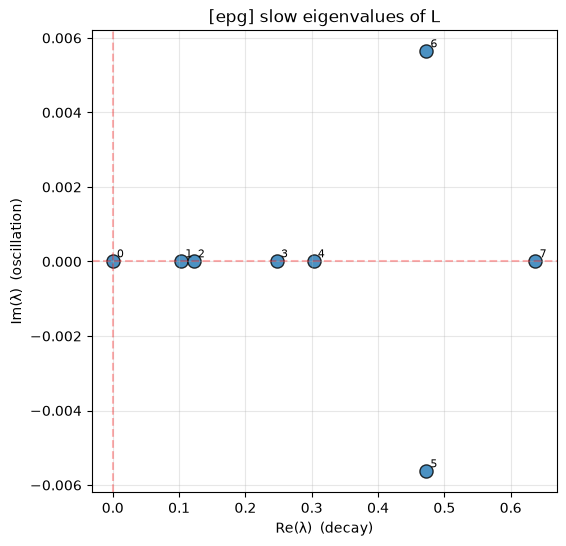

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_pairgrid.pdf


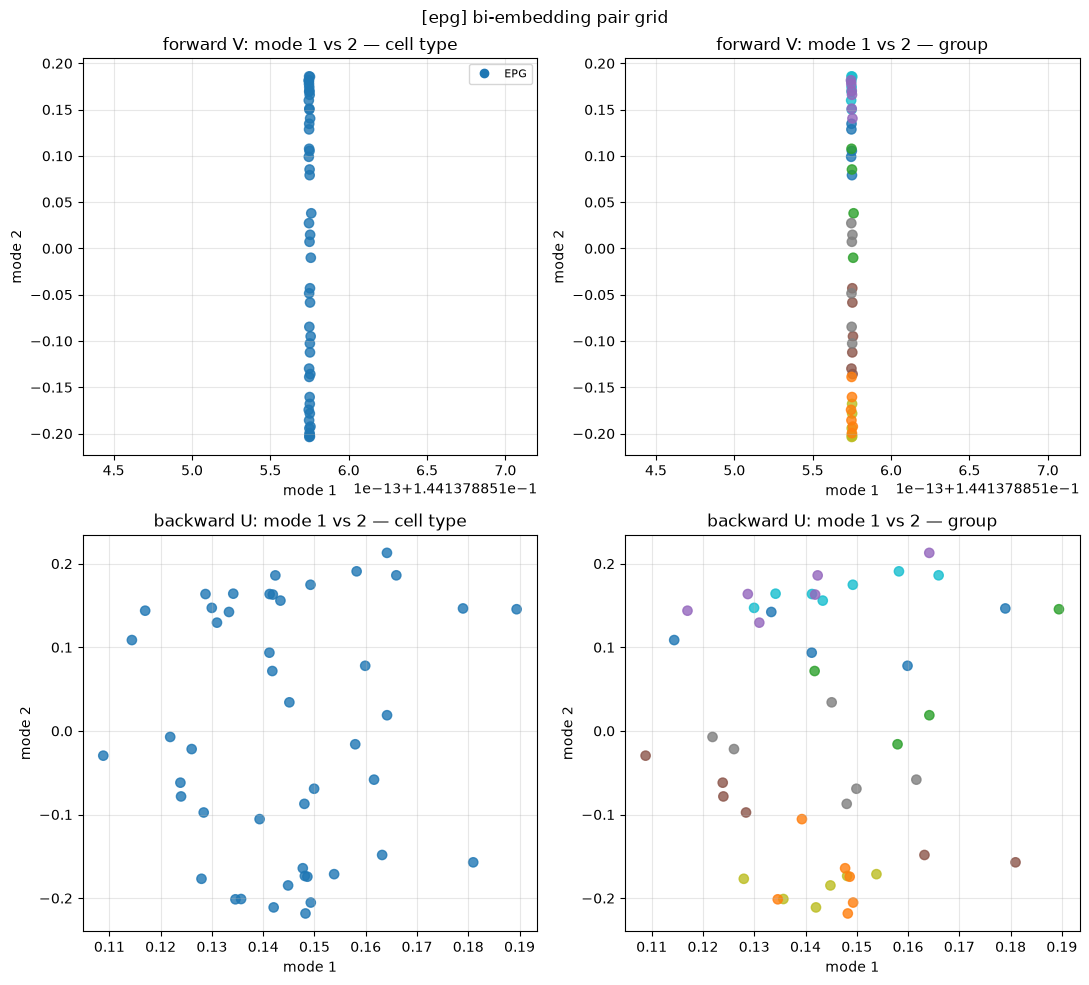

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_ring_manifold.pdf


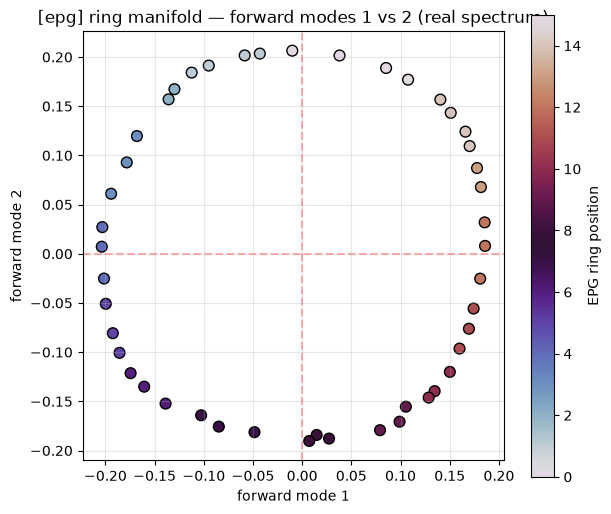

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_ring_manifold_backward.pdf


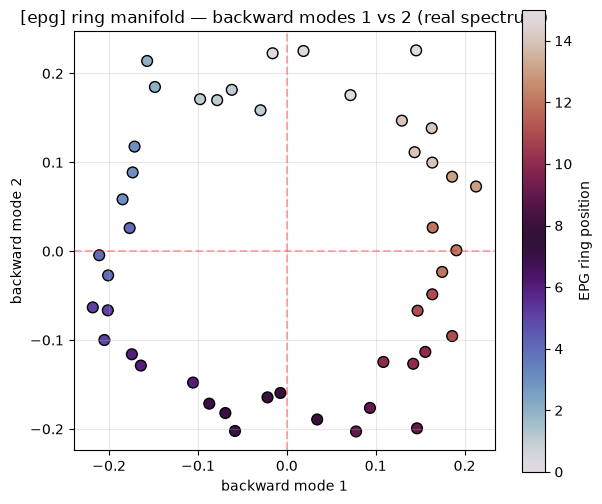

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_mode_profiles.pdf


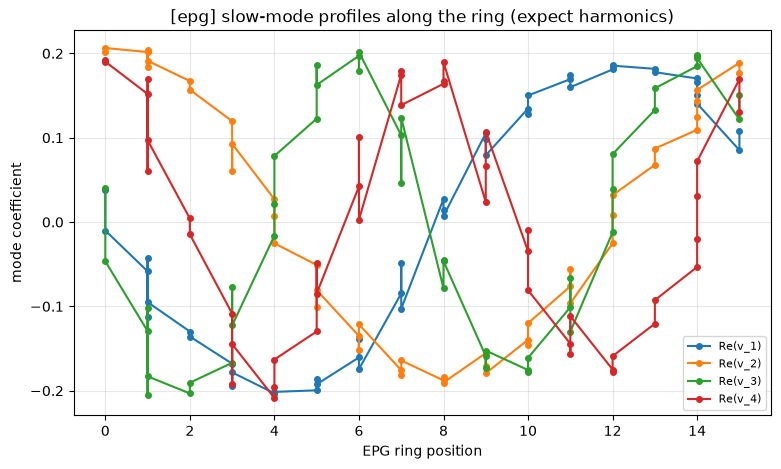

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_roles.pdf


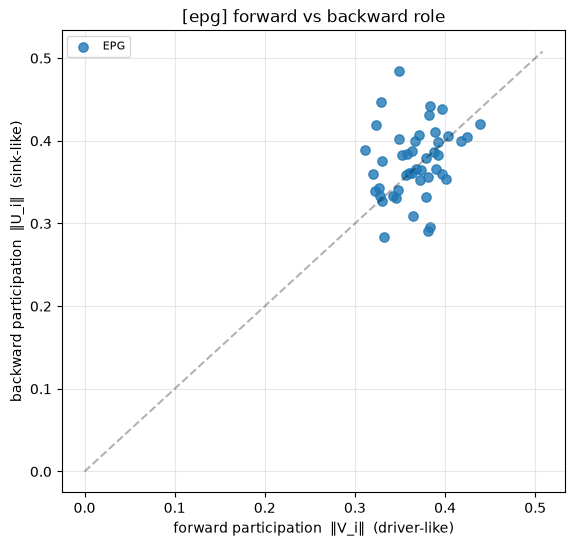

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_projection.pdf


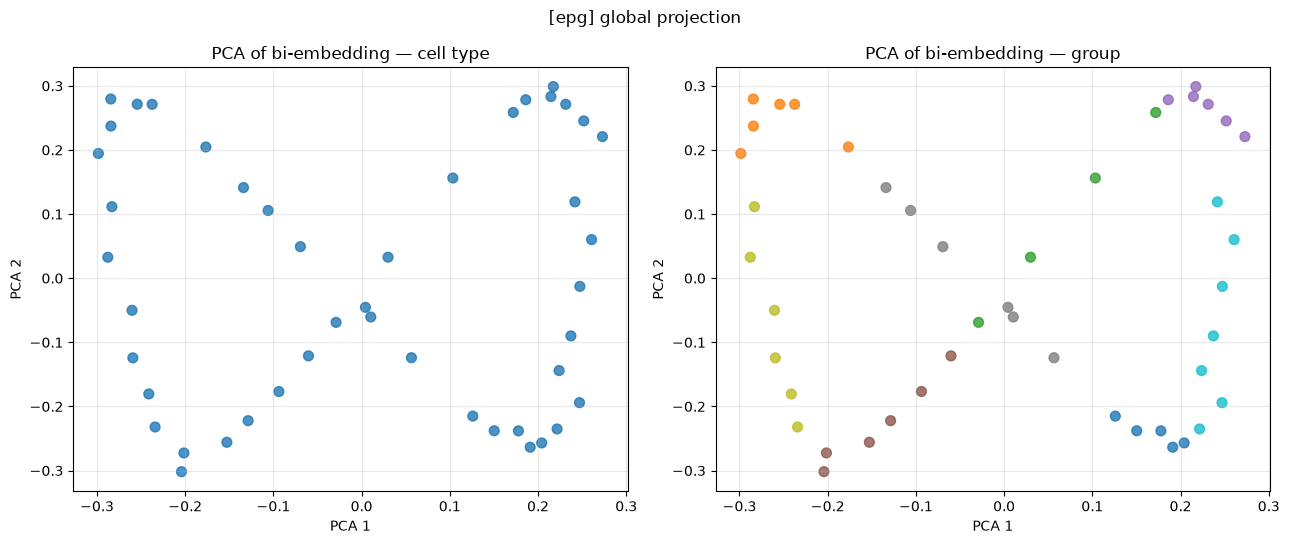

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_contingency.pdf


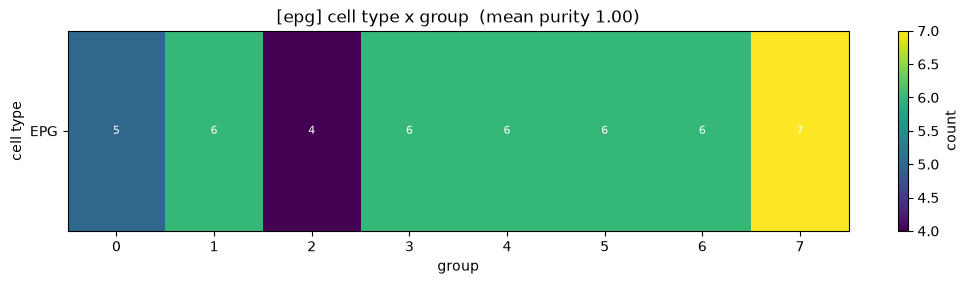

group      0  1  2  3  4  5  6  7
cell type                        
EPG        5  6  4  6  6  6  6  7


In [4]:
rc_epg = load_ring_connectome(['EPG'], reorder='spatial')
b_epg = explore_population(rc_epg, 'epg', backward_proj=True)

## Pass 2 — Delta7 + EPG combined

The full compass circuit (88 neurons), clustered into **9 groups** (`k=9`).
Spectral seriation ordering; the EPG ring coordinate is retained where available
(Delta7 has none).

[d7epg] n=88  k=9  groups=9  fidelity=3.7952
[d7epg] genuinely oscillatory slow modes (|Im|/|Re|>0.1): 0/9
saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_spectrum.pdf


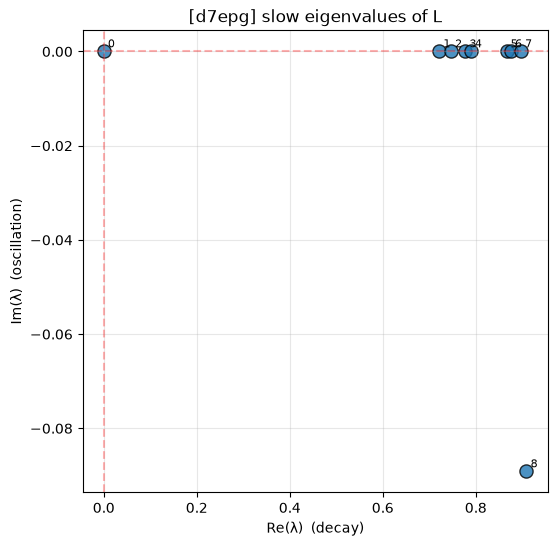

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_pairgrid.pdf


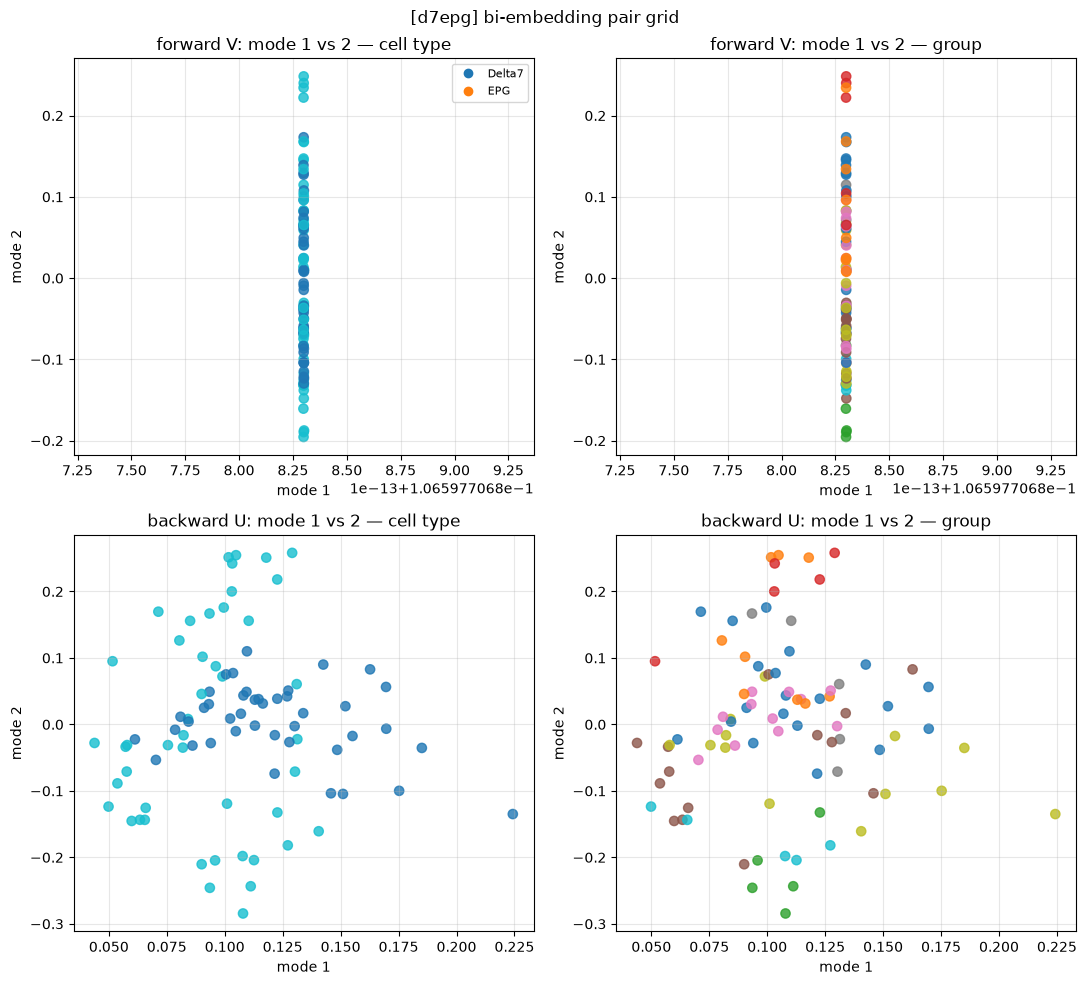

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_ring_manifold.pdf


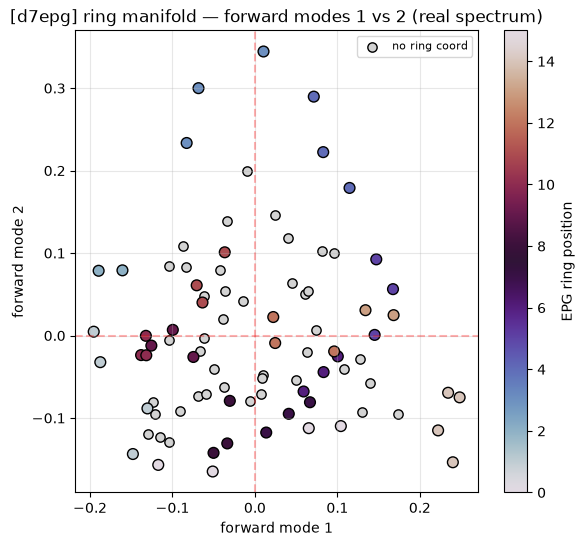

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_mode_profiles.pdf


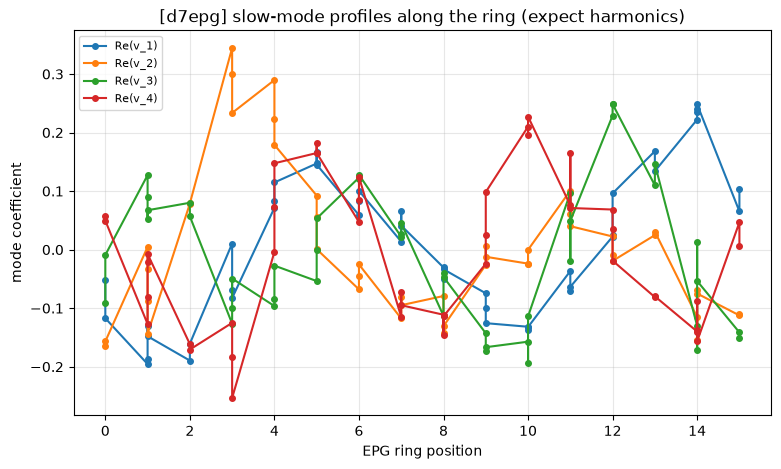

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_roles.pdf


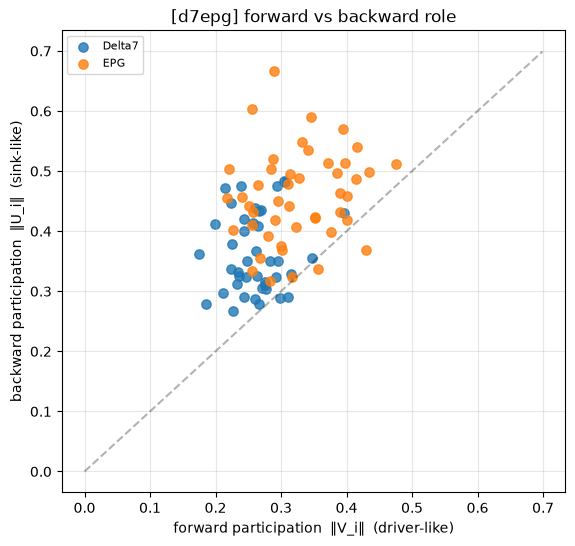

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_projection.pdf


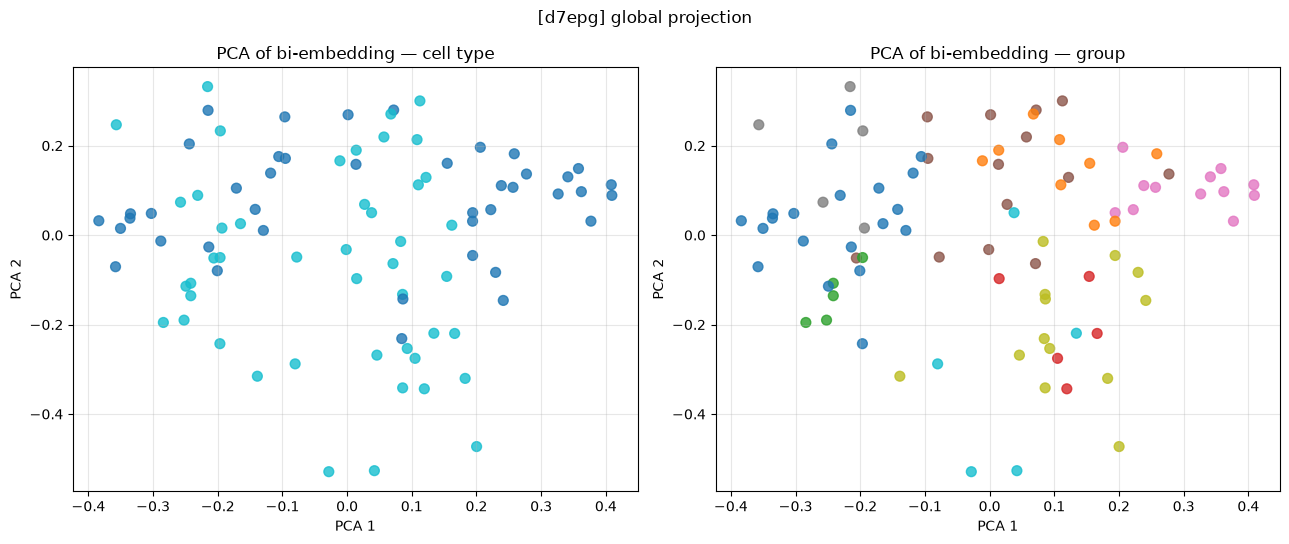

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_contingency.pdf


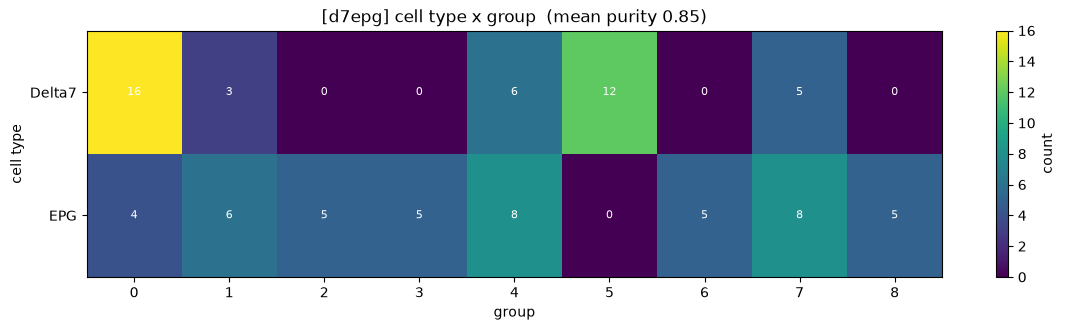

group       0  1  2  3  4   5  6  7  8
cell type                             
Delta7     16  3  0  0  6  12  0  5  0
EPG         4  6  5  5  8   0  5  8  5


In [5]:
rc_all = load_ring_connectome(['Delta7', 'EPG'], reorder='seriation')
b_all = explore_population(rc_all, 'd7epg', k=9)   # 9 clusters

### Cross-population: which slow modes does each cell type dominate?

Mean absolute forward-mode coefficient per slow mode, split by cell type — shows
whether the slow dynamics are carried more by EPG or Delta7.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_mode_participation.pdf


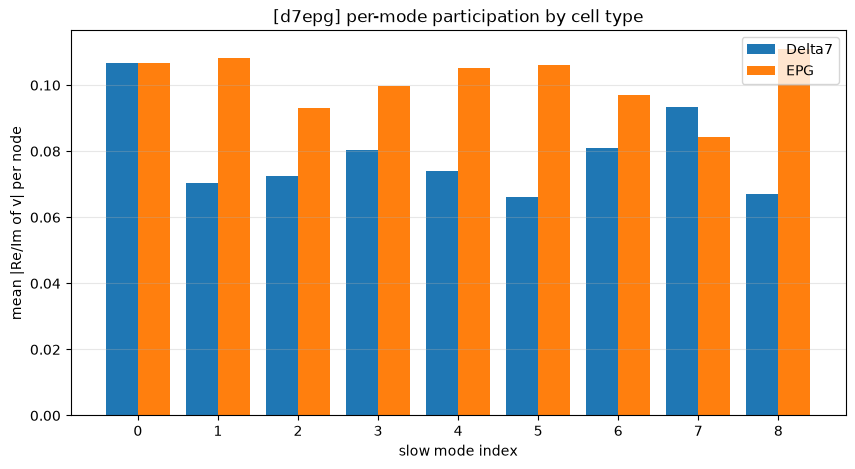

In [6]:
k = b_all['k']
ctoi = b_all['ctoi']; V = np.abs(b_all['V_c'])
types = sorted(set(ctoi.tolist()))
modes = np.arange(k)
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.8 / len(types)
for i, t in enumerate(types):
    msk = ctoi == t
    ax.bar(modes + i * w, V[msk].mean(axis=0), width=w, label=t)
ax.set_xlabel('slow mode index'); ax.set_ylabel('mean |Re/Im of v| per node')
ax.set_xticks(modes + w * (len(types) - 1) / 2); ax.set_xticklabels(modes)
ax.set_title('[d7epg] per-mode participation by cell type'); ax.legend(); ax.grid(alpha=.3, axis='y')
save_pdf(fig, 'biort_d7epg_mode_participation'); plt.show()

### Delta7 + EPG combined connectivity

The connectivity matrix of the full population, ordered by cell type so the
Delta7 and EPG blocks (and the cross-blocks between them) are contiguous.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_connectivity.pdf


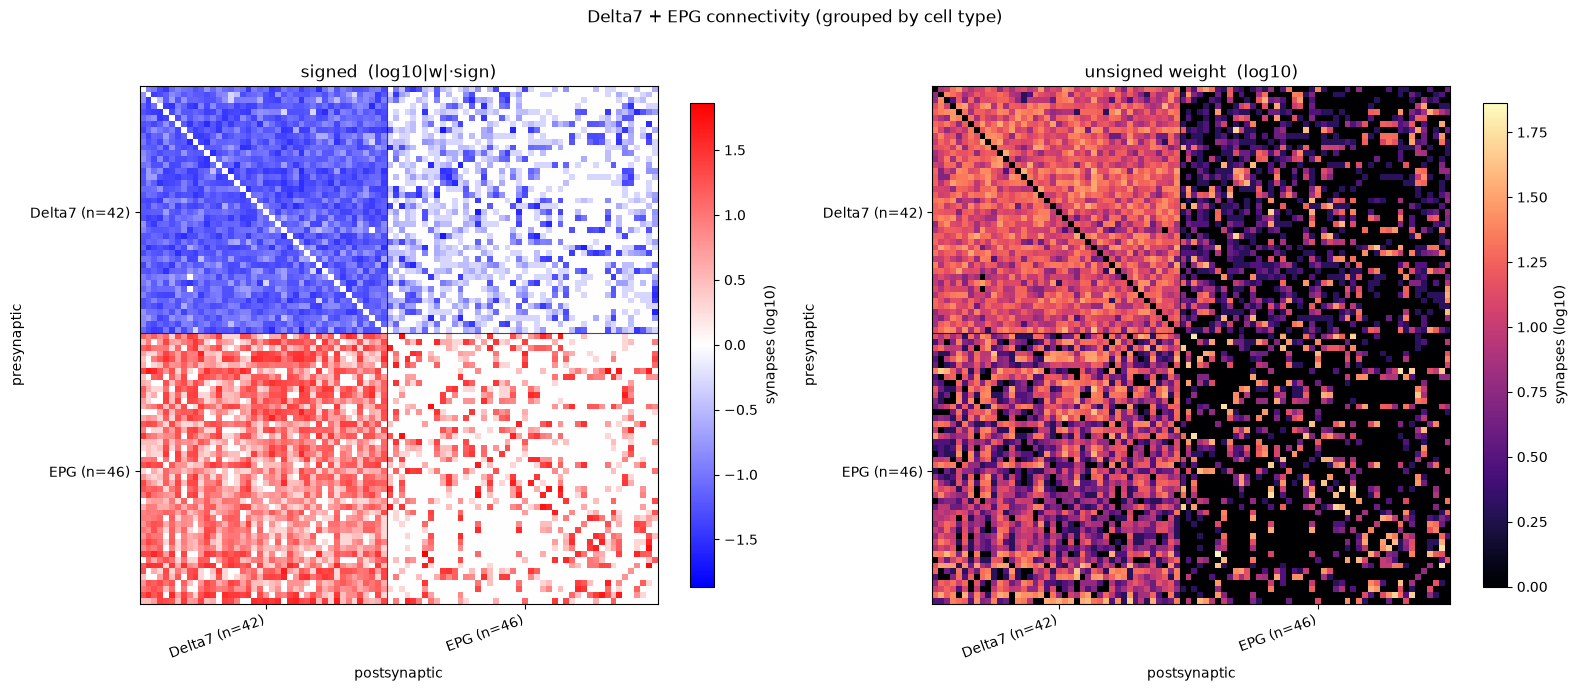

In [7]:
rc_conn = load_ring_connectome(['Delta7', 'EPG'], reorder=None)  # cell-type-grouped order
C = rc_conn.C_signed
A = rc_conn.A
ctoi = np.array(rc_conn.ctoi)

# Cell-type block boundaries and centered tick labels.
bounds, ticks, labels, pos = [], [], [], 0
for t in rc_conn.unique_cell_types:
    nt = int((ctoi == t).sum())
    ticks.append(pos + nt / 2); labels.append(f'{t} (n={nt})')
    pos += nt; bounds.append(pos)

Msigned = np.log10(np.abs(C) + 1) * np.sign(C)
vmax = np.max(np.abs(Msigned))
Munsigned = np.log10(A + 1)

fig, axs = plt.subplots(1, 2, figsize=(16, 7))
im0 = axs[0].imshow(Msigned, cmap='bwr', vmin=-vmax, vmax=vmax, interpolation='none')
axs[0].set_title('signed  (log10|w|·sign)'); fig.colorbar(im0, ax=axs[0], shrink=.8, label='synapses (log10)')
im1 = axs[1].imshow(Munsigned, cmap='magma', interpolation='none')
axs[1].set_title('unsigned weight  (log10)'); fig.colorbar(im1, ax=axs[1], shrink=.8, label='synapses (log10)')
for ax in axs:
    for b in bounds[:-1]:
        ax.axhline(b - 0.5, c='k', lw=.8, alpha=.7); ax.axvline(b - 0.5, c='k', lw=.8, alpha=.7)
    ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_yticks(ticks); ax.set_yticklabels(labels)
    ax.set_xlabel('postsynaptic'); ax.set_ylabel('presynaptic')
fig.suptitle('Delta7 + EPG connectivity (grouped by cell type)'); fig.tight_layout()
save_pdf(fig, 'biort_d7epg_connectivity'); plt.show()

show_plotly(go.Figure(
    go.Heatmap(z=Msigned, colorscale='RdBu', zmid=0, colorbar=dict(title='log10·sign')),
    layout=dict(title='Delta7 + EPG signed connectivity (cell-type order)',
                xaxis_title='postsynaptic', yaxis_title='presynaptic',
                yaxis=dict(autorange='reversed'), width=720, height=680)))

### Does k=2 separate the two cell types?

The bi-orthogonal embedding is fit on the **unsigned** adjacency, so its slow
modes organize neurons by shared ring topology — not by excitatory/inhibitory
identity (which lives in the discarded sign). With `k=2` the split is therefore
essentially uncorrelated with cell type.

biort group (k=2)   0   1
cell type                
Delta7             21  21
EPG                22  24

ARI vs cell type: -0.011   mean purity: 0.522   (0 / 0.5 = no separation)
saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_k2_celltype.pdf


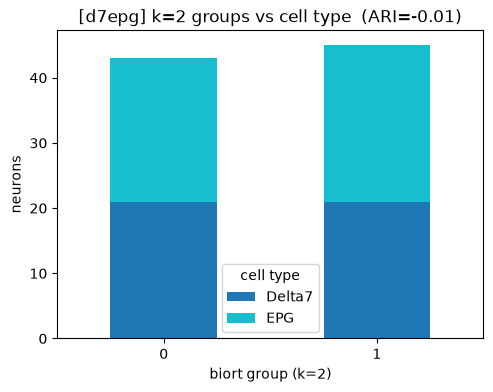

In [8]:
from sklearn.metrics import adjusted_rand_score

be2 = BiorthEmbedding(k=2, alpha=0.95, realify=True, random_state=42).fit(rc_all.A)
g2 = np.asarray(be2.groups_)
tab2 = pd.crosstab(pd.Series(rc_all.ctoi, name='cell type'),
                   pd.Series(g2, name='biort group (k=2)'))
ari = adjusted_rand_score([0 if c == 'Delta7' else 1 for c in rc_all.ctoi], g2)
purity = (tab2.max(axis=0) / tab2.sum(axis=0)).mean()
print(tab2)
print(f"\nARI vs cell type: {ari:.3f}   mean purity: {purity:.3f}   "
      f"(0 / 0.5 = no separation)")

fig, ax = plt.subplots(figsize=(5.5, 4))
tab2.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('biort group (k=2)'); ax.set_ylabel('neurons')
ax.set_title(f'[d7epg] k=2 groups vs cell type  (ARI={ari:.2f})')
ax.legend(title='cell type'); ax.tick_params(axis='x', rotation=0)
save_pdf(fig, 'biort_d7epg_k2_celltype'); plt.show()

## SVD co-embedding — recovering cell type from directed unsigned structure

The slow bi-orthogonal modes miss cell type, but the leading **singular vectors**
of the directed unsigned adjacency capture the source/sink role that separates
EPG (out-heavy) from Delta7 (in-heavy). Each node is co-embedded from the top
singular vectors of `A`: left vectors `U` (out-role) and right vectors `V`
(in-role), stacked as `[Uₖ·Sₖ | Vₖ·Sₖ]`. We compare **EPG alone** (one cell type
→ internal ring structure) with **Delta7 + EPG** (two types → clean K=2 split).

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_svd.pdf


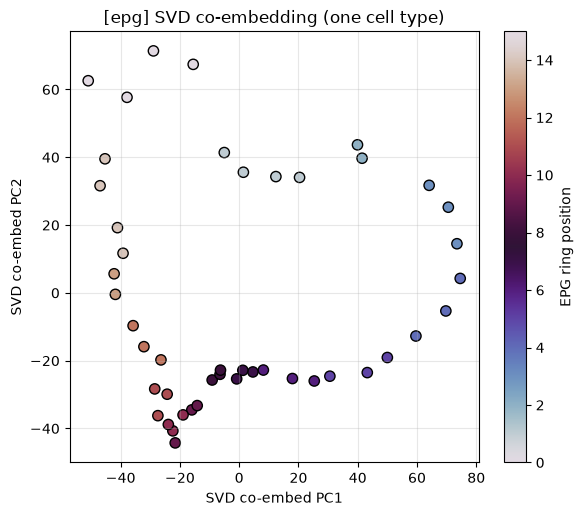

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def svd_coembedding(A, d=4):
    """Co-embed nodes from the top-d singular vectors: [U_d*S_d | V_d*S_d]."""
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    d = min(d, len(S))
    return np.c_[U[:, :d] * S[:d], Vt[:d].T * S[:d]]

# --- EPG alone: single cell type -> SVD reveals internal (ring) structure ----
emb_e = svd_coembedding(rc_epg.A, d=4)
P_e = PCA(n_components=2, random_state=0).fit_transform(emb_e)
ring_e = np.asarray(rc_epg.ring_pos)
fig, ax = plt.subplots(figsize=(6.6, 5.6))
sc = ax.scatter(P_e[:, 0], P_e[:, 1], c=ring_e, cmap='twilight', s=55, edgecolors='k')
fig.colorbar(sc, ax=ax, label='EPG ring position')
ax.set_xlabel('SVD co-embed PC1'); ax.set_ylabel('SVD co-embed PC2')
ax.set_title('[epg] SVD co-embedding (one cell type)'); ax.grid(alpha=.3)
save_pdf(fig, 'biort_epg_svd'); plt.show()
show_plotly(px.scatter(
    x=P_e[:, 0], y=P_e[:, 1], color=ring_e,
    hover_name=[f'{n}<br>{ci}' for n, ci in zip(rc_epg.noi, rc_epg.cioi)],
    color_continuous_scale='twilight', labels={'x': 'PC1', 'y': 'PC2', 'color': 'ring'},
    title='[epg] SVD co-embedding'))

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_svd.pdf


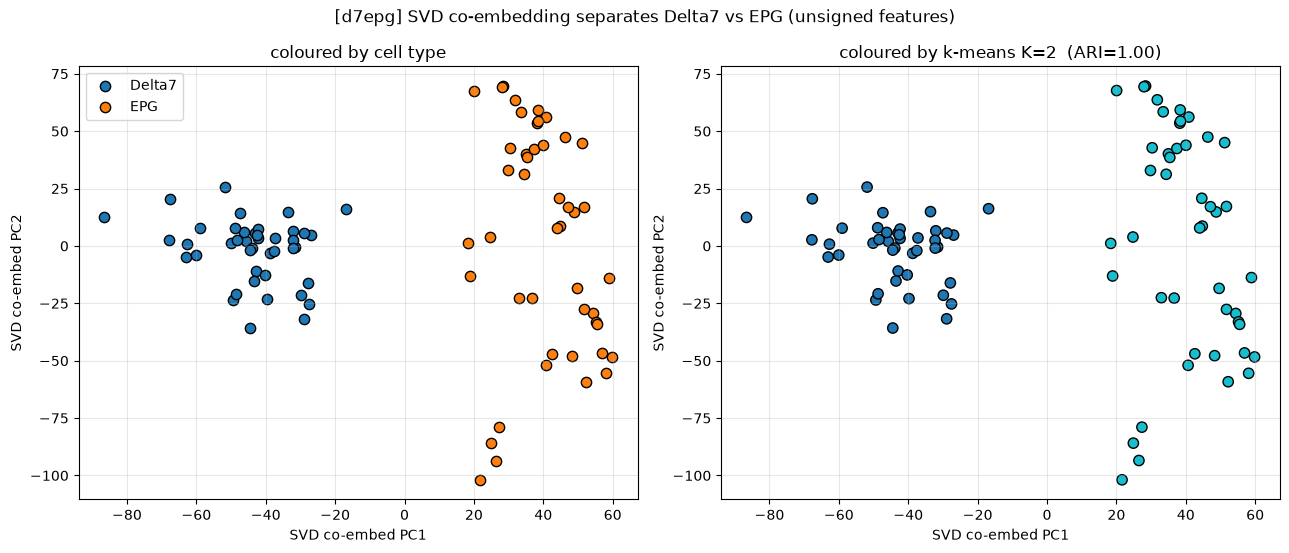

SVD k-means (K=2)   0   1
cell type                
Delta7             42   0
EPG                 0  46

ARI vs cell type: 1.000  (1.0 = perfect separation)


In [10]:
# --- Delta7 + EPG: SVD co-embedding separates the two cell types -------------
emb_a = svd_coembedding(rc_all.A, d=4)
P_a = PCA(n_components=2, random_state=0).fit_transform(emb_a)
ct = np.array(rc_all.ctoi)
y_true = np.array([0 if c == 'Delta7' else 1 for c in ct])
lab = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(emb_a)
ari = adjusted_rand_score(y_true, lab)
types = sorted(set(ct.tolist()))
hover_a = [f'{n}<br>{ci}<br>{c}' for n, ci, c in zip(rc_all.noi, rc_all.cioi, ct)]

fig, axs = plt.subplots(1, 2, figsize=(13, 5.6))
for i, t in enumerate(types):
    m = ct == t
    axs[0].scatter(P_a[m, 0], P_a[m, 1], s=55, edgecolors='k', label=t, color=plt.cm.tab10(i / 10))
axs[0].set_title('coloured by cell type'); axs[0].legend()
axs[1].scatter(P_a[:, 0], P_a[:, 1], c=lab, cmap='tab10', s=55, edgecolors='k')
axs[1].set_title(f'coloured by k-means K=2  (ARI={ari:.2f})')
for ax in axs:
    ax.set_xlabel('SVD co-embed PC1'); ax.set_ylabel('SVD co-embed PC2'); ax.grid(alpha=.3)
fig.suptitle('[d7epg] SVD co-embedding separates Delta7 vs EPG (unsigned features)')
fig.tight_layout(); save_pdf(fig, 'biort_d7epg_svd'); plt.show()

tab = pd.crosstab(pd.Series(ct, name='cell type'), pd.Series(lab, name='SVD k-means (K=2)'))
print(tab)
print(f'\nARI vs cell type: {ari:.3f}  (1.0 = perfect separation)')
show_plotly(px.scatter(
    x=P_a[:, 0], y=P_a[:, 1], color=ct, hover_name=hover_a,
    labels={'x': 'PC1', 'y': 'PC2'}, title='[d7epg] SVD co-embedding by cell type'))

## Three spectral embeddings compared: diffusion `eig(L)`, `eig(A)`, SVD

Three unsigned spectral embeddings of the same matrix, side by side:

- **diffusion** — slow eigenvectors of the random-walk Laplacian `L = I − P`,
  `P = D_out⁻¹A` (row-normalized → out-degree erased). *Dynamics of the walk.*
- **eig(A)** — dominant eigenvectors of the **raw** adjacency `A`. *Dynamics of
  `x → Ax` (centrality / invariant directions), magnitudes kept.*
- **SVD** — leading singular vectors of `A`. *Geometry / dominant connection
  pattern.*

For EPG alone (near-normal) all three recover the ring. For Delta7+EPG only SVD
separates the cell types — both eigen-methods track invariant/mixing structure,
not the block-role contrast.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_three_methods.pdf


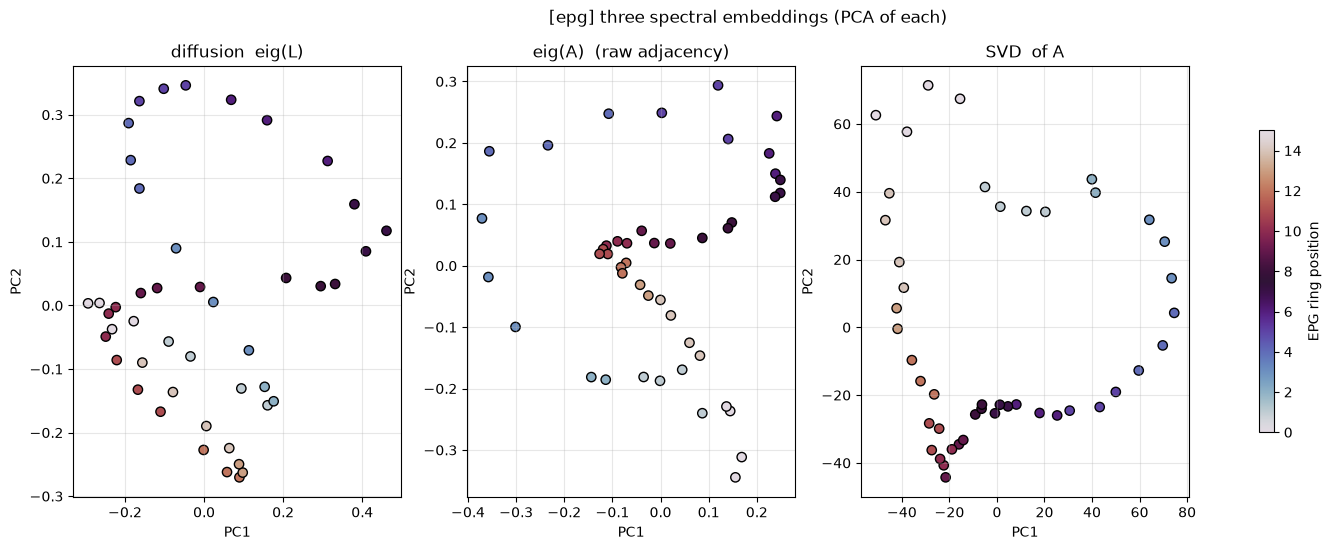

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_three_methods.pdf


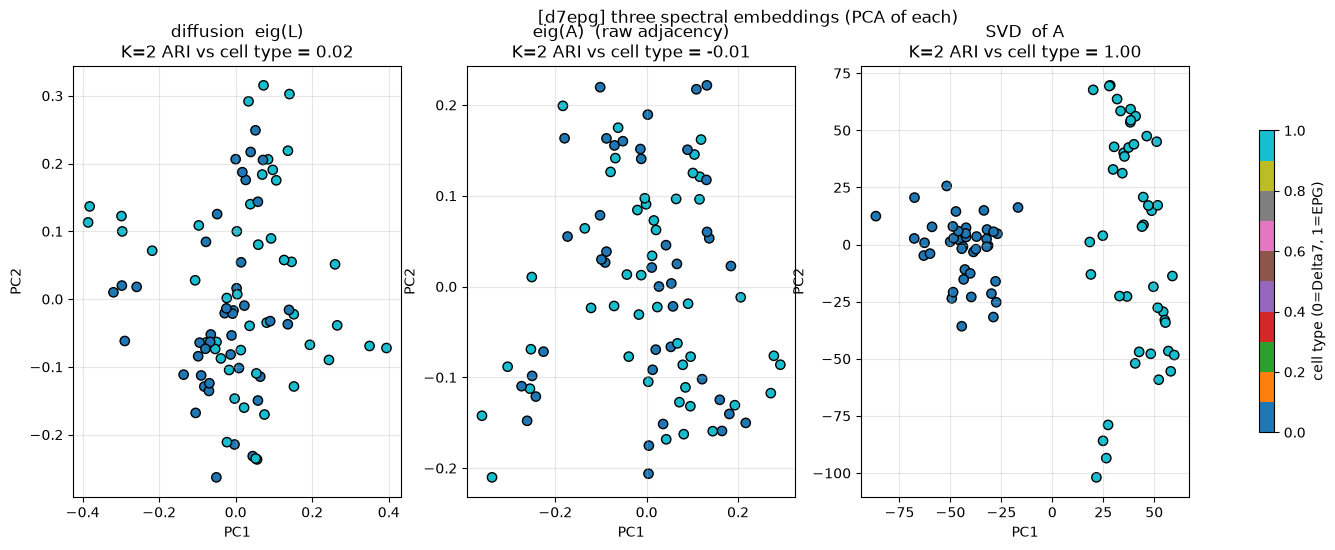

Delta7+EPG  K=2 ARI vs cell type: {'diffusion  eig(L)': 0.022, 'eig(A)  (raw adjacency)': -0.009, 'SVD  of A': 1.0}


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def embed_eigL(A, d=6):
    """Slow eigenvectors of the random-walk Laplacian (drop the stationary mode)."""
    P = A / A.sum(1)[:, None]
    w, V = np.linalg.eig(np.eye(len(A)) - P)
    V = V[:, np.argsort(np.abs(w))[1:d + 1]]
    return np.c_[np.real(V), np.imag(V)]

def embed_eigA(A, d=6):
    """Dominant eigenvectors of the raw adjacency, by |lambda|."""
    w, V = np.linalg.eig(A)
    V = V[:, np.argsort(-np.abs(w))[:d]]
    return np.c_[np.real(V), np.imag(V)]

# svd_coembedding(A, d) defined in the SVD section above.

def compare_three(rc, tag, color, clabel, cmap, truth=None):
    A = rc.A
    methods = [('diffusion  eig(L)', embed_eigL(A, 6)),
               ('eig(A)  (raw adjacency)', embed_eigA(A, 6)),
               ('SVD  of A', svd_coembedding(A, 4))]
    fig, axs = plt.subplots(1, 3, figsize=(18, 5.6))
    aris = {}
    for ax, (name, E) in zip(axs, methods):
        P = PCA(n_components=2, random_state=0).fit_transform(E)
        sc = ax.scatter(P[:, 0], P[:, 1], c=color, cmap=cmap, s=45, edgecolors='k')
        ttl = name
        if truth is not None:
            a = adjusted_rand_score(truth, KMeans(2, n_init=10, random_state=0).fit_predict(E))
            aris[name] = a; ttl += f'\nK=2 ARI vs cell type = {a:.2f}'
        ax.set_title(ttl); ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=.3)
    fig.colorbar(sc, ax=axs, label=clabel, shrink=.7)
    fig.suptitle(f'[{tag}] three spectral embeddings (PCA of each)')
    save_pdf(fig, f'biort_{tag}_three_methods'); plt.show()
    return aris

# EPG alone — colour by ring position; all three should trace the ring.
compare_three(rc_epg, 'epg', np.asarray(rc_epg.ring_pos), 'EPG ring position', 'twilight')

# Delta7+EPG — colour by cell type; only SVD separates (ARI in titles).
ct = np.array(rc_all.ctoi)
tcode = np.array([sorted(set(ct.tolist())).index(c) for c in ct])
ytrue = np.array([0 if c == 'Delta7' else 1 for c in ct])
aris = compare_three(rc_all, 'd7epg', tcode, 'cell type (0=Delta7, 1=EPG)', 'tab10', truth=ytrue)
print('Delta7+EPG  K=2 ARI vs cell type:', {k: round(v, 3) for k, v in aris.items()})

### Diagnostics & benchmarks (reproducible source for the analysis doc)

Every number quoted in `docs/spectral_embeddings.md` is computed here: structural
diagnostics per dataset, and the two benchmarks per method — **EPG ring
correlation** and **Delta7 + EPG cell-type ARI**.

In [12]:
from scipy.stats import pearsonr

def diagnostics(A):
    P = A / A.sum(1)[:, None]
    gap = np.sort(np.abs(np.linalg.eigvals(np.eye(len(A)) - P)))[1]   # 2nd-smallest |eig(L)|
    S = np.linalg.svd(A, compute_uv=False)
    eA = np.sort(np.abs(np.linalg.eigvals(A)))[::-1]
    return {
        'asymmetry ||A-A^T||/||A+A^T||': round(np.linalg.norm(A - A.T) / np.linalg.norm(A + A.T), 3),
        'non-normality ||AA^T-A^TA||/||A||^2': round(np.linalg.norm(A @ A.T - A.T @ A) / np.linalg.norm(A) ** 2, 3),
        'diffusion spectral gap': round(gap, 3),
        'top singular values': np.round(S[:4], 1).tolist(),
        'top |eig(A)|': np.round(eA[:4], 1).tolist(),
    }

diag = pd.DataFrame({'EPG': diagnostics(rc_epg.A), 'Delta7+EPG': diagnostics(rc_all.A)})
print('=== structural diagnostics ==='); print(diag, '\n')

# Two "diffusion" computations are benchmarked side by side (see the doc):
#   biort bi-embedding : BiorthEmbedding(alpha=0.95, realify) -> [Re(V)|Re(U)] (fwd+bwd)
#   eig(L) hand-rolled : right eigenvectors of I - D_out^-1 A (no teleport), [Re|Im]
def embed_biort(A, k=6):                                # full bi-embedding [Re(V)|Re(U)]
    return BiorthEmbedding(k=k, alpha=0.95, realify=True, random_state=42).fit(A).get_embedding()
def biort_fwd(A, k=6):  return embed_biort(A, k)[:, :k]        # forward (right) modes
def biort_bwd(A, k=6):  return embed_biort(A, k)[:, k:2 * k]   # backward (left) modes

ang = 2 * np.pi * np.asarray(rc_epg.ring_pos) / 16.0
def ring_corr(x):
    return max(abs(pearsonr(x, np.cos(ang))[0]), abs(pearsonr(x, np.sin(ang))[0]))

def leading_modes(A, method, n=4):
    # Best ring harmonic over the leading n non-trivial modes (skip the constant
    # stationary / Perron mode where present) so methods compare on equal footing.
    if method == 'SVD':
        U = np.linalg.svd(A, full_matrices=False)[0]; return [U[:, i] for i in range(n)]
    if method == 'eig(A)':
        w, V = np.linalg.eig(A); idx = np.argsort(-np.abs(w))
        return [np.real(V[:, idx[i]]) for i in range(n)]
    if method.startswith('biort'):
        X = embed_biort(A, 6); Xf, Xb = X[:, :6], X[:, 6:12]   # forward / backward blocks
        if method == 'biort_fwd':  return [Xf[:, i + 1] for i in range(n)]   # skip stationary col 0
        if method == 'biort_bwd':  return [Xb[:, i + 1] for i in range(n)]
        return [Xf[:, 1], Xf[:, 2], Xb[:, 1], Xb[:, 2]]        # both: leading fwd + bwd
    P = A / A.sum(1)[:, None]; w, V = np.linalg.eig(np.eye(len(A)) - P); idx = np.argsort(np.abs(w))
    return [np.real(V[:, idx[i + 1]]) for i in range(n)]   # eig(L): skip stationary

embed_fns = {
    'diffusion biort (forward)':    lambda A: biort_fwd(A, 6),
    'diffusion biort (backward)':   lambda A: biort_bwd(A, 6),
    'diffusion biort (fwd+bwd)':    lambda A: embed_biort(A, 6),
    'diffusion eig(L) hand-rolled': lambda A: embed_eigL(A, 6),
    'eig(A)':                       lambda A: embed_eigA(A, 6),
    'SVD':                          lambda A: svd_coembedding(A, 4),
}
ringkey = {
    'diffusion biort (forward)':    'biort_fwd',
    'diffusion biort (backward)':   'biort_bwd',
    'diffusion biort (fwd+bwd)':    'biort_both',
    'diffusion eig(L) hand-rolled': 'eig(L)',
    'eig(A)': 'eig(A)', 'SVD': 'SVD',
}
ytrue = np.array([0 if c == 'Delta7' else 1 for c in rc_all.ctoi])
bench = pd.DataFrame([
    {'method': m,
     'EPG ring corr': round(max(ring_corr(x) for x in leading_modes(rc_epg.A, ringkey[m])), 2),
     'Delta7+EPG cell-type ARI': round(
         adjusted_rand_score(ytrue, KMeans(2, n_init=10, random_state=0).fit_predict(embed_fns[m](rc_all.A))), 2)}
    for m in embed_fns]).set_index('method')
print('=== benchmarks ==='); print(bench, '\n')

w, V = np.linalg.eig(rc_all.A); idx = np.argsort(-np.abs(w))
print(f"Perron eig(A): |lambda|={abs(w[idx][0]):.0f}, "
      f"|corr| vs cell type={abs(pearsonr(np.real(V[:, idx[0]]), ytrue)[0]):.2f}")

=== structural diagnostics ===
                                                              EPG  \
asymmetry ||A-A^T||/||A+A^T||                               0.164   
non-normality ||AA^T-A^TA||/||A||^2                         0.092   
diffusion spectral gap                                      0.056   
top singular values                  [190.8, 171.6, 150.6, 135.9]   
top |eig(A)|                         [188.1, 169.4, 147.2, 132.2]   

                                                       Delta7+EPG  
asymmetry ||A-A^T||/||A+A^T||                               0.491  
non-normality ||AA^T-A^TA||/||A||^2                         0.316  
diffusion spectral gap                                      0.707  
top singular values                  [753.3, 308.5, 293.2, 187.5]  
top |eig(A)|                         [701.2, 160.4, 160.4, 133.1]   



=== benchmarks ===
                              EPG ring corr  Delta7+EPG cell-type ARI
method                                                               
diffusion biort (forward)              0.99                     -0.01
diffusion biort (backward)             0.91                      0.27
diffusion biort (fwd+bwd)              0.99                      0.24
diffusion eig(L) hand-rolled           0.99                      0.02
eig(A)                                 0.84                     -0.01
SVD                                    0.80                      1.00 

Perron eig(A): |lambda|=701, |corr| vs cell type=0.68


### Figure: six embeddings × two datasets

Rows are the six embeddings — the bi-embedding split into **forward**, **backward**,
and **forward+backward**, plus the hand-rolled `eig(L)`, `eig(A)`, and SVD. Left
column is EPG alone (colour = ring position), right column is Delta7 + EPG
(colour = cell type, K=2 ARI in each title). Each panel is **PCA(2) of that
method's full embedding matrix** (the n×features array), used only to project to
2-D for display; clustering/ARI uses the full embedding. Saved as PNG + PDF.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_embeddings_grid.pdf


saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_embeddings_grid.png


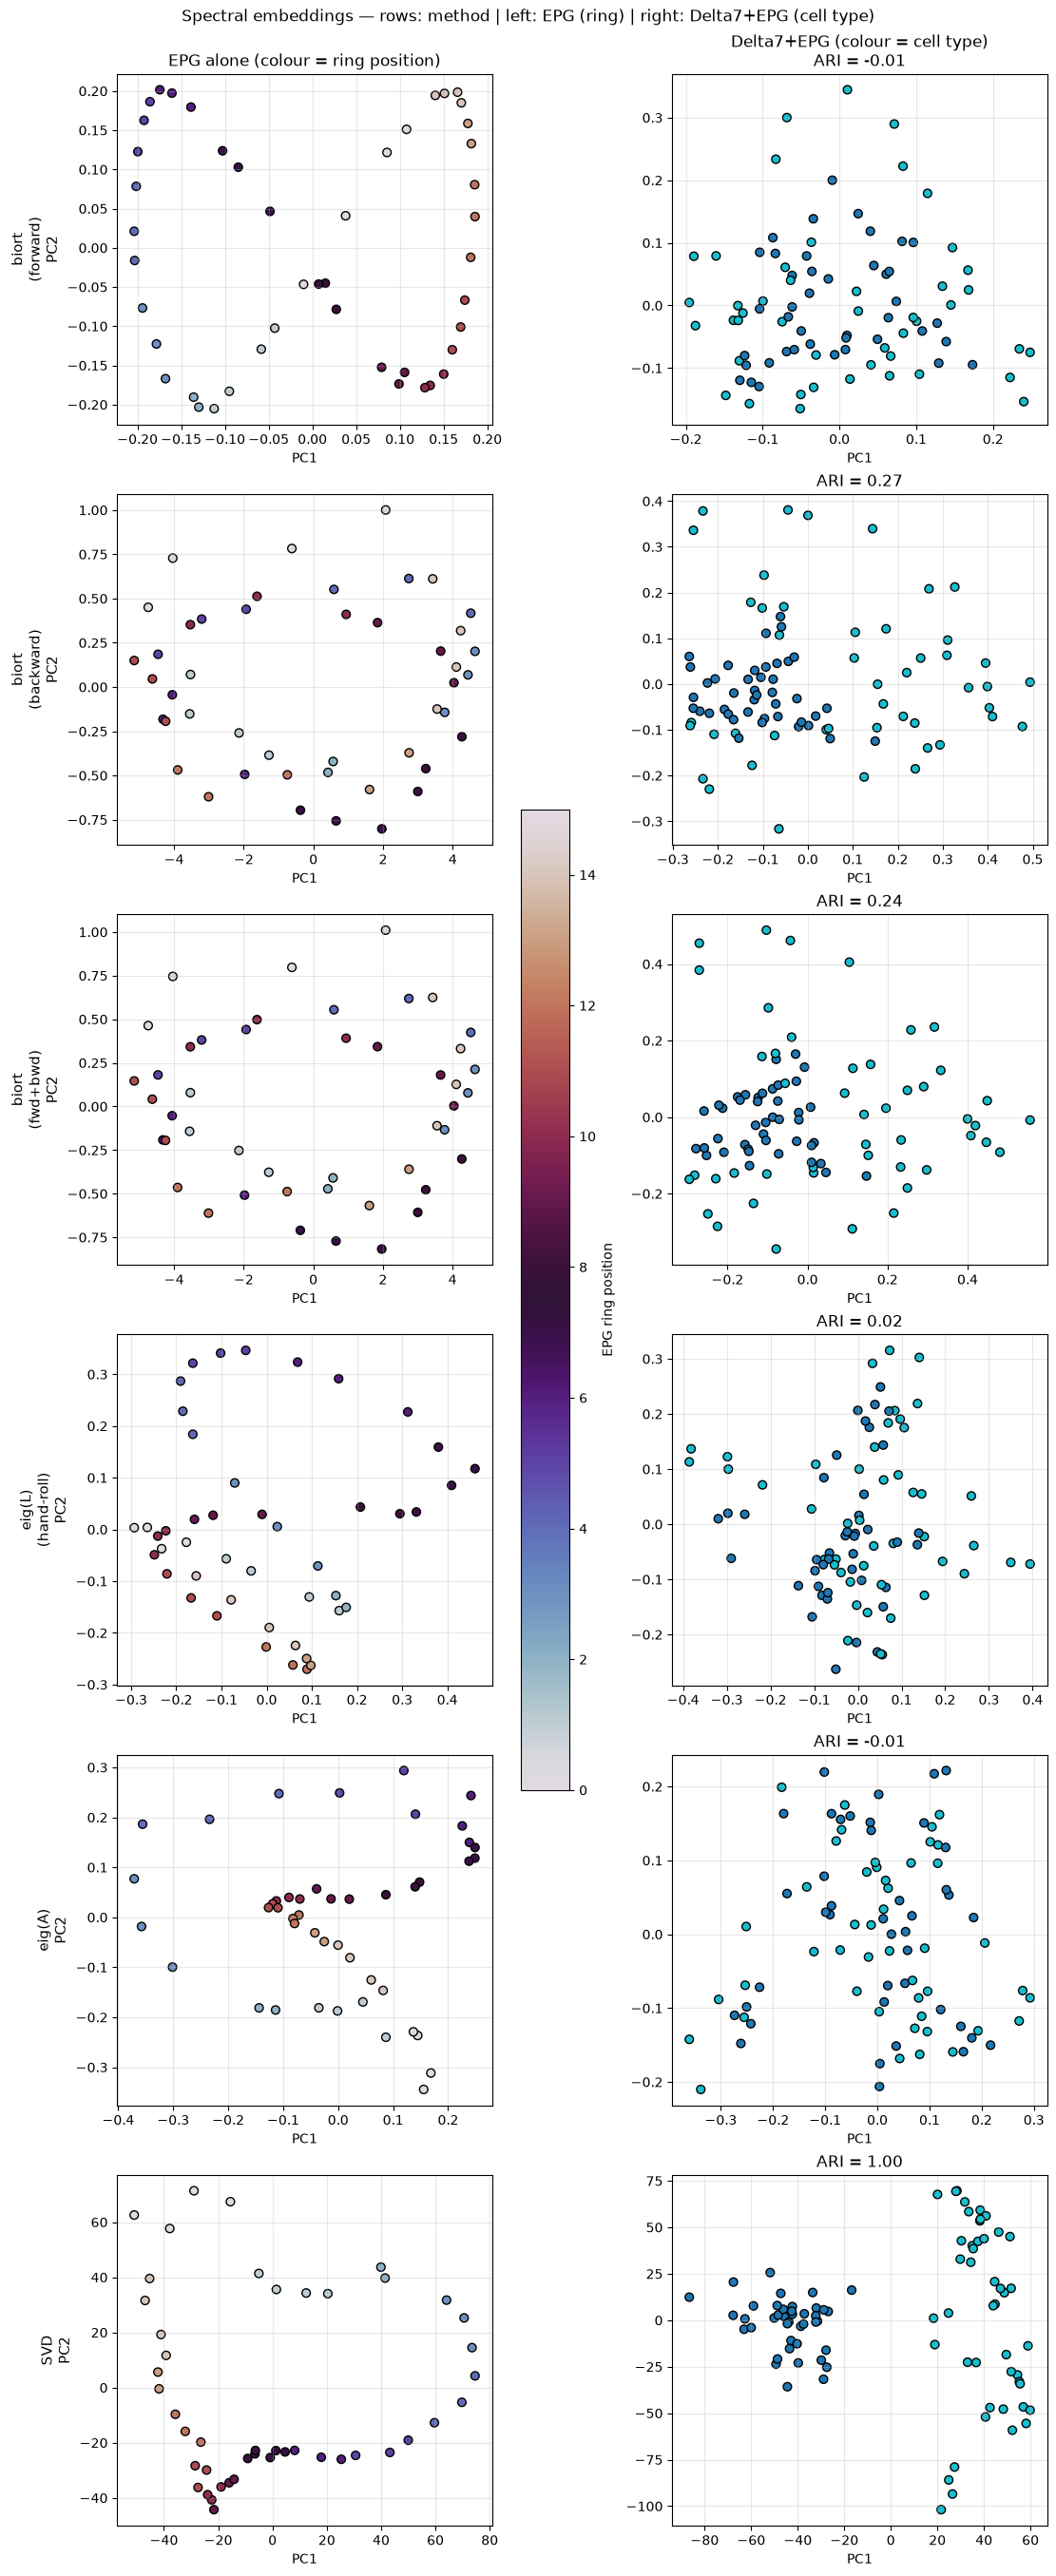

In [13]:
grid_methods = [('biort\n(forward)', lambda A: biort_fwd(A, 6)),
                ('biort\n(backward)', lambda A: biort_bwd(A, 6)),
                ('biort\n(fwd+bwd)', lambda A: embed_biort(A, 6)),
                ('eig(L)\n(hand-roll)', lambda A: embed_eigL(A, 6)),
                ('eig(A)', lambda A: embed_eigA(A, 6)),
                ('SVD', lambda A: svd_coembedding(A, 4))]
ring_e = np.asarray(rc_epg.ring_pos)
ct = np.array(rc_all.ctoi); tcode = np.array([sorted(set(ct.tolist())).index(c) for c in ct])

fig, axs = plt.subplots(6, 2, figsize=(11, 27), constrained_layout=True)
for r, (name, fn) in enumerate(grid_methods):
    Pe = PCA(n_components=2, random_state=0).fit_transform(fn(rc_epg.A))
    sc = axs[r, 0].scatter(Pe[:, 0], Pe[:, 1], c=ring_e, cmap='twilight', s=40, edgecolors='k')
    axs[r, 0].set_ylabel(f'{name}\nPC2', fontsize=11)
    Ea = fn(rc_all.A); Pa = PCA(n_components=2, random_state=0).fit_transform(Ea)
    ari = adjusted_rand_score(ytrue, KMeans(2, n_init=10, random_state=0).fit_predict(Ea))
    axs[r, 1].scatter(Pa[:, 0], Pa[:, 1], c=tcode, cmap='tab10', s=40, edgecolors='k')
    axs[r, 1].set_title(('Delta7+EPG (colour = cell type)\n' if r == 0 else '') + f'ARI = {ari:.2f}')
    if r == 0:
        axs[r, 0].set_title('EPG alone (colour = ring position)')
    for c in (0, 1):
        axs[r, c].set_xlabel('PC1'); axs[r, c].grid(alpha=.3)
fig.colorbar(sc, ax=axs[:, 0], label='EPG ring position', shrink=.4)
fig.suptitle('Spectral embeddings — rows: method | left: EPG (ring) | right: Delta7+EPG (cell type)',
             fontsize=12)
save_pdf(fig, 'biort_embeddings_grid')
fig.savefig(os.path.join(FIG_DIR, 'biort_embeddings_grid.png'), dpi=150, bbox_inches='tight')
print('saved', os.path.join(FIG_DIR, 'biort_embeddings_grid.png'))
plt.show()

### Sanity check — direct top-2 column projections

The grid above uses PCA(2) of each embedding (a rotation). Here we instead plot
each embedding's **leading two columns directly** on EPG (coloured by ring), to
confirm the doc's `embed_*` helpers produce the expected structure, and that the
PCA panels are just rotations of these. We also check numerically that the doc's
biort forward modes are exactly the ones the `biort_epg_ring_manifold` panel
plots.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_sanity_direct_cols.pdf


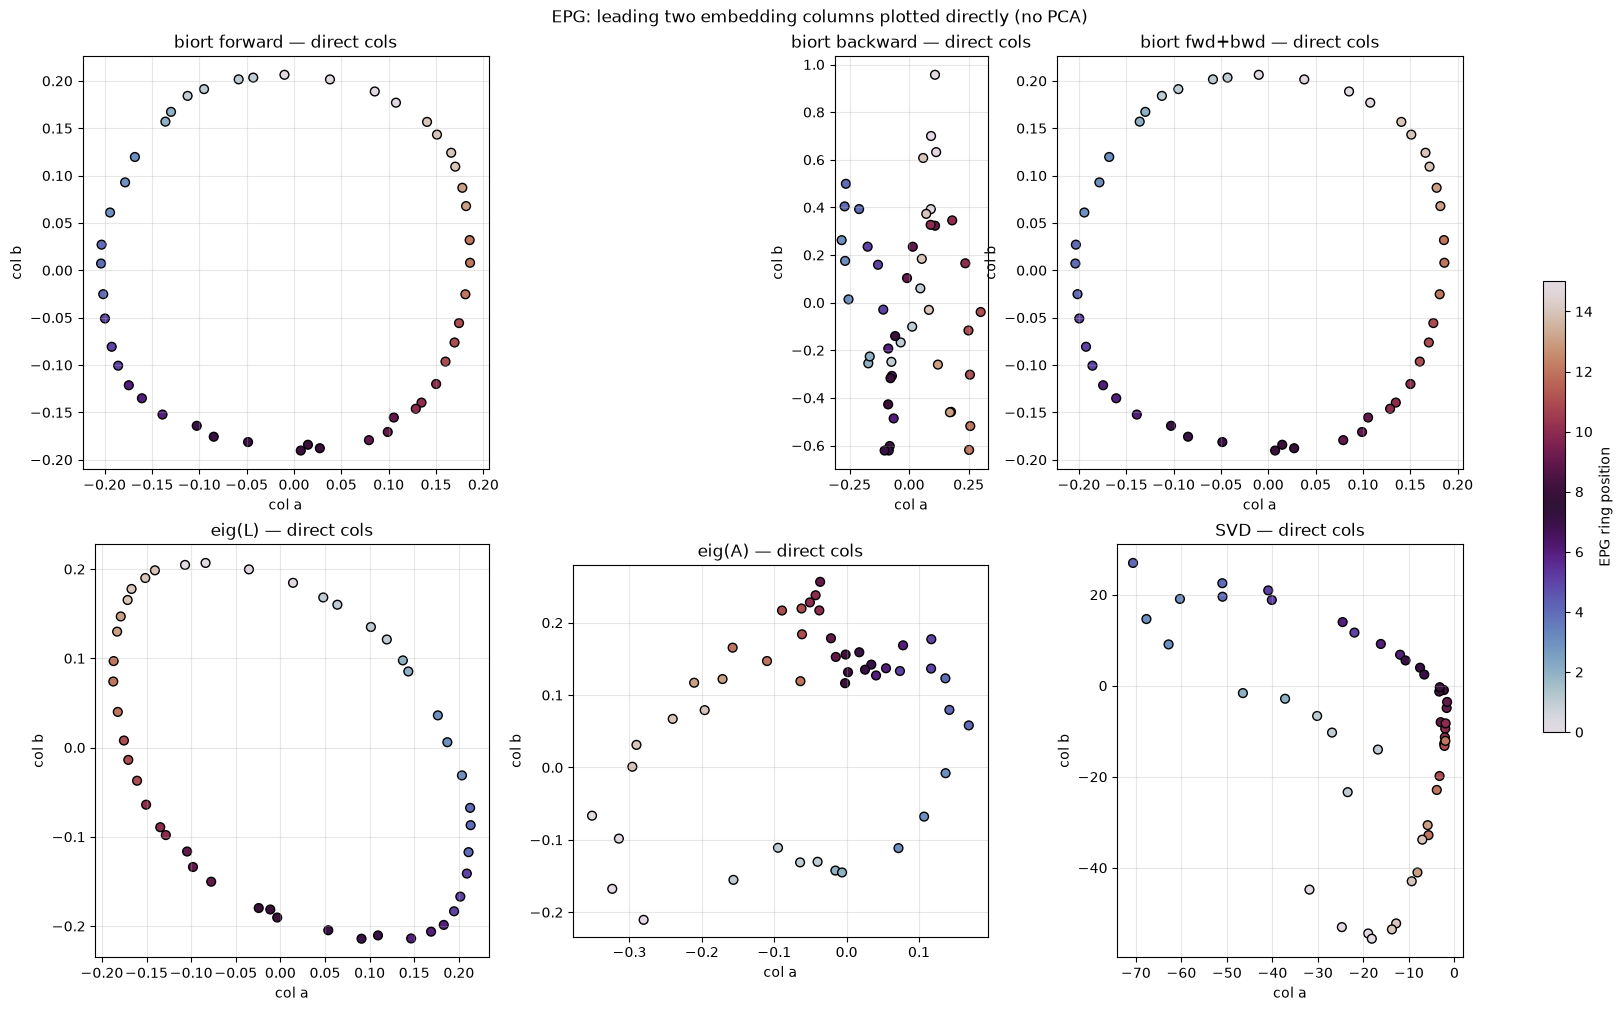

max |diff| of forward cols 1,2 between k=6 (doc) and k=8 (ring-manifold): 0.00e+00


In [14]:
def direct_cols(method, A):
    if method == 'biort forward':  X = biort_fwd(A, 6);   return X[:, 1], X[:, 2]
    if method == 'biort backward': X = biort_bwd(A, 6);   return X[:, 1], X[:, 2]
    if method == 'biort fwd+bwd':  X = embed_biort(A, 6); return X[:, 1], X[:, 2]
    if method == 'eig(L)':         X = embed_eigL(A, 6);  return X[:, 0], X[:, 1]
    if method == 'eig(A)':         X = embed_eigA(A, 6);  return X[:, 1], X[:, 2]
    X = svd_coembedding(A, 4);                            return X[:, 0], X[:, 1]

methods6 = ['biort forward', 'biort backward', 'biort fwd+bwd', 'eig(L)', 'eig(A)', 'SVD']
fig, axs = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
for ax, m in zip(axs.ravel(), methods6):
    x, y = direct_cols(m, rc_epg.A)
    sc = ax.scatter(x, y, c=ring_e, cmap='twilight', s=40, edgecolors='k')
    ax.set_title(f'{m} — direct cols'); ax.set_aspect('equal'); ax.grid(alpha=.3)
    ax.set_xlabel('col a'); ax.set_ylabel('col b')
fig.colorbar(sc, ax=axs, label='EPG ring position', shrink=.5)
fig.suptitle('EPG: leading two embedding columns plotted directly (no PCA)')
save_pdf(fig, 'biort_sanity_direct_cols'); plt.show()

# Numerical: biort forward modes used in the doc match the ring-manifold panel's.
# The ring-manifold (EPG pass) uses BiorthEmbedding(k=8); the comparison uses k=6.
Xf8 = BiorthEmbedding(k=8, alpha=0.95, realify=True, random_state=42).fit(rc_epg.A).get_embedding()[:, :8]
Xf6 = biort_fwd(rc_epg.A, 6)
def cols_equal(a, b, j):              # equal up to an overall sign per column
    return min(np.max(np.abs(a[:, j] - b[:, j])), np.max(np.abs(a[:, j] + b[:, j])))
print('max |diff| of forward cols 1,2 between k=6 (doc) and k=8 (ring-manifold):',
      f'{max(cols_equal(Xf6, Xf8, 1), cols_equal(Xf6, Xf8, 2)):.2e}')

### Figure (no PCA): six embeddings × two datasets, direct columns

Same layout as the PCA grid, but each panel plots the embedding's **leading two
columns directly** (the columns listed in `direct_cols`) instead of PCA(2). This
is the version embedded in the doc as the no-PCA companion. K=2 ARI (right column)
is still computed on the **full** embedding.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_embeddings_grid_directcols.pdf


saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_embeddings_grid_directcols.png


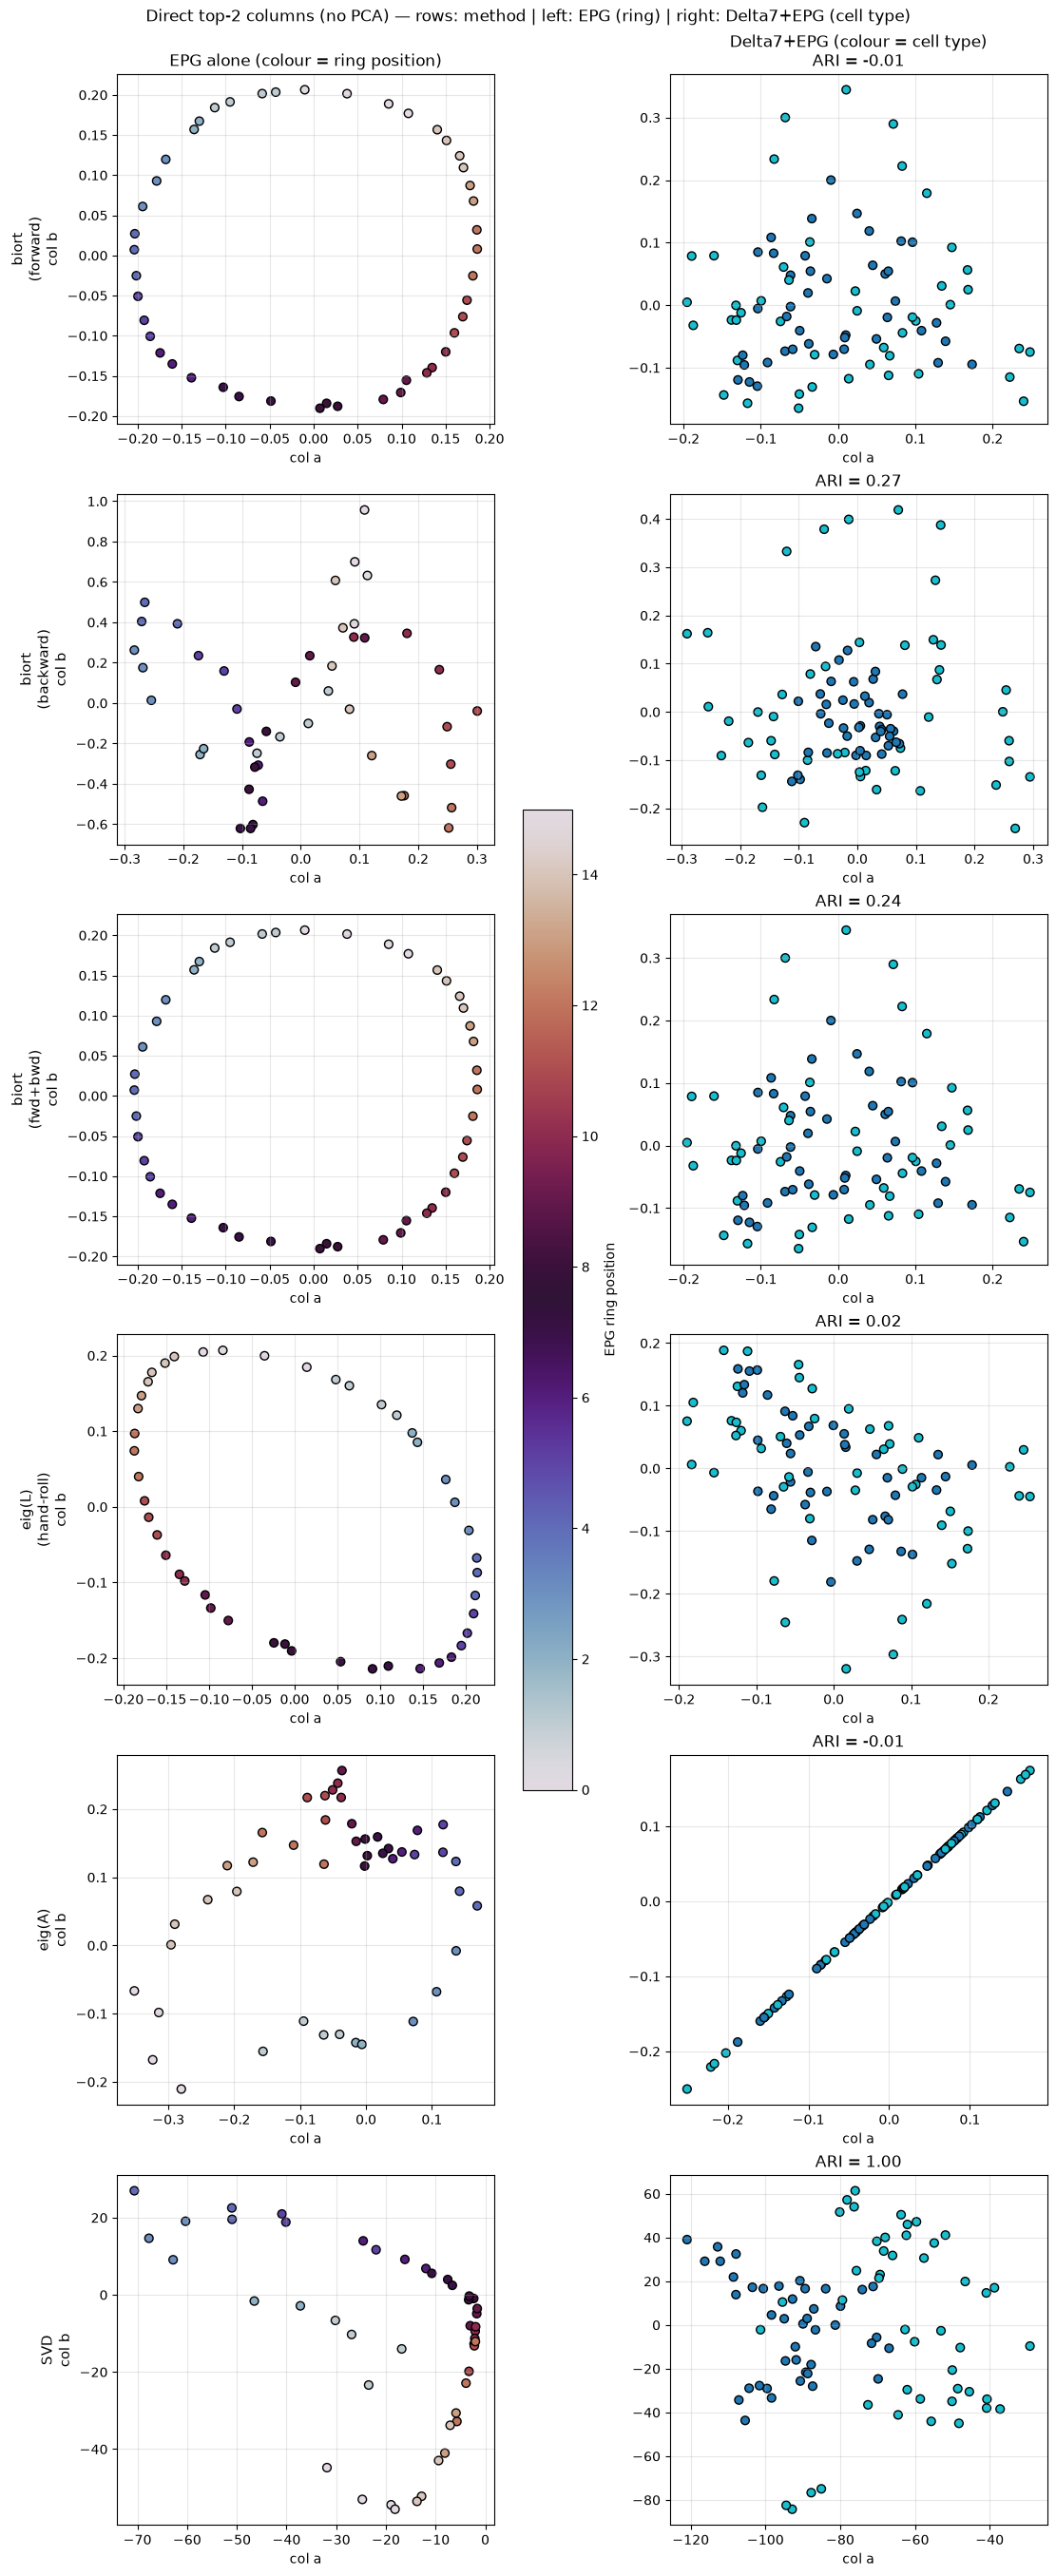

In [15]:
grid_dc = [('biort\n(forward)',  'biort forward',  lambda A: biort_fwd(A, 6)),
           ('biort\n(backward)', 'biort backward', lambda A: biort_bwd(A, 6)),
           ('biort\n(fwd+bwd)',  'biort fwd+bwd',  lambda A: embed_biort(A, 6)),
           ('eig(L)\n(hand-roll)', 'eig(L)',       lambda A: embed_eigL(A, 6)),
           ('eig(A)', 'eig(A)',                     lambda A: embed_eigA(A, 6)),
           ('SVD', 'SVD',                           lambda A: svd_coembedding(A, 4))]

fig, axs = plt.subplots(6, 2, figsize=(11, 27), constrained_layout=True)
for r, (rowlab, dckey, fn) in enumerate(grid_dc):
    xe, ye = direct_cols(dckey, rc_epg.A)
    sc = axs[r, 0].scatter(xe, ye, c=ring_e, cmap='twilight', s=40, edgecolors='k')
    axs[r, 0].set_ylabel(f'{rowlab}\ncol b', fontsize=11)
    xa, ya = direct_cols(dckey, rc_all.A)
    ari = adjusted_rand_score(ytrue, KMeans(2, n_init=10, random_state=0).fit_predict(fn(rc_all.A)))
    axs[r, 1].scatter(xa, ya, c=tcode, cmap='tab10', s=40, edgecolors='k')
    axs[r, 1].set_title(('Delta7+EPG (colour = cell type)\n' if r == 0 else '') + f'ARI = {ari:.2f}')
    if r == 0:
        axs[r, 0].set_title('EPG alone (colour = ring position)')
    for c in (0, 1):
        axs[r, c].set_xlabel('col a'); axs[r, c].grid(alpha=.3)
fig.colorbar(sc, ax=axs[:, 0], label='EPG ring position', shrink=.4)
fig.suptitle('Direct top-2 columns (no PCA) — rows: method | left: EPG (ring) | right: Delta7+EPG (cell type)',
             fontsize=12)
save_pdf(fig, 'biort_embeddings_grid_directcols')
fig.savefig(os.path.join(FIG_DIR, 'biort_embeddings_grid_directcols.png'), dpi=150, bbox_inches='tight')
print('saved', os.path.join(FIG_DIR, 'biort_embeddings_grid_directcols.png'))
plt.show()